In [14]:
import zarr

In [15]:
z = zarr.open('E:/Chronos1m.zarr', mode='r+')

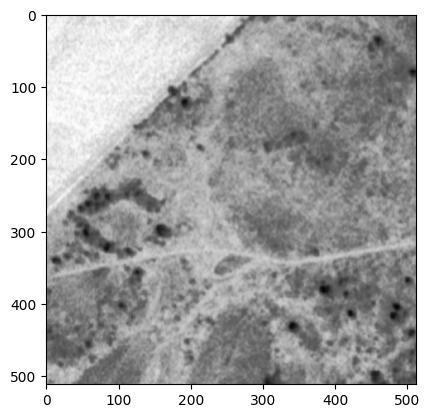

In [48]:
plt.imshow(z['eros_hist'][142, 0, :512, :512], cmap='gray')

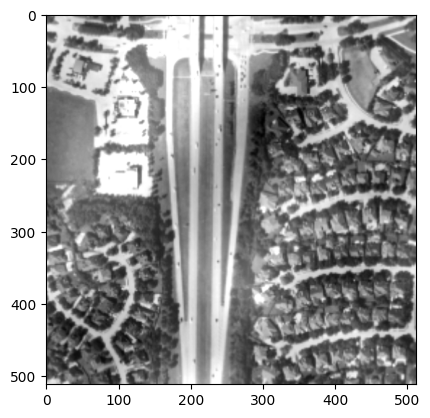

In [47]:
plt.imshow(z['naip_hist'][142, 1, :512, :512], cmap='gray')

In [3]:
label_dist = z['metrics/dist/urbanwatch']
labels = z['masks/urbanwatch']

In [4]:
metadata = z.attrs['metadata']

In [5]:
masks = z['masks']

In [36]:
masks.create_array(
    'distances',
    shape=(343, 7000, 6000),
    chunks=(1, 7000, 6000),
    dtype='uint16',
    fill_value=0,
    compressors=zarr.codecs.BloscCodec(cname='lz4', clevel=5, shuffle="shuffle")
)

<Array file://E:/Chronos1m.zarr/masks/distances shape=(343, 7000, 6000) dtype=uint16>

In [40]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def compute_boundary_dist(label, i):
    boundaries = np.zeros_like(label, dtype=bool)

    # Mark boundaries where label changes between adjacent pixels
    boundaries[:-1, :] |= (label[:-1, :] != label[1:, :])
    boundaries[:, :-1] |= (label[:, :-1] != label[:, 1:])

    # Distance to nearest boundary
    dist = distance_transform_edt(~boundaries)
    masks['distances'][i] = dist.astype(np.uint16)[0]

for i in range(labels.shape[0]):
    compute_boundary_dist(labels[i], i)

In [ ]:
import numpy as np

from pyproj import Transformer

def aligned_centroid(meta, target_crs="EPSG:5070"):
    left, bottom, right, top = meta["bounds"]
    cx = (left + right) / 2
    cy = (bottom + top) / 2
    src_crs = meta["crs"]
    transformer = Transformer.from_crs(src_crs, target_crs, always_xy=True)
    cx_t, cy_t = transformer.transform(cx, cy)
    return [cx_t, cy_t]

def compute_centroid(tile):
    x_min, y_min, x_max, y_max = tile['bounds']
    return ((x_min + x_max) / 2, (y_min + y_max) / 2)

def compute_tile_metadata(label_distribution, metadata_tiles):
    metadata = []

    for i, (hist, tile) in enumerate(zip(label_distribution, metadata_tiles)):
        # label histogram
        p = hist / hist.sum()

        # fetch the centroid from the metadata
        centroid = aligned_centroid(tile)

        # entropy (higher = more mixed labels)
        entropy = -(p[p > 0] * np.log(p[p > 0])).sum()

        metadata.append({
            "tile_id": i,
            "centroid": centroid,
            "entropy": entropy.item()
        })

    return metadata

In [ ]:
tile_metadata = compute_tile_metadata(label_dist, metadata['tiles'])

In [1]:
import sys

sys.path.append('..')

In [2]:
from chronos.data.chrono_module import ChronosDataModule

In [3]:
dm = ChronosDataModule(
    zarr_dir='E:/Chronos1m.zarr',
    batch_size=2,
    workers=1,
    keep_query=True)

In [4]:
dm.setup()

In [5]:
dl = dm.train_dataloader()

In [6]:
sample = next(iter(dl))

In [7]:
import matplotlib.pyplot as plt

In [21]:
z.attrs['metadata']['lookup_idx_to_id']['142']

'HOU_70_LULC'

In [22]:
import pandas as pd

In [24]:
df = pd.read_csv('E:/scene_metadata.csv')

In [37]:
big = df.explode('tile_id')

In [42]:
def gsd(flying_height_ft, focal_length_mm, scan_microns):
    H_mm = flying_height_ft * 0.3048 * 1000      # ft → m → mm
    p_mm = scan_microns / 1000                  # microns → mm
    gsd_mm = (H_mm * p_mm) / focal_length_mm
    return gsd_mm / 1000

In [40]:
big['adj_scale'] = 1.0 / big['scale']

In [43]:
big['GSD'] = big.apply(lambda row: gsd(row['flying_height_feet'], row['focal_length'], 25), axis=1)

In [44]:
big[big['tile_id'] == 'HOU_70_LULC']

,photo_id,state,city,agency,recording_technique,acquisition_date,scale,image_type,quality,cloud_cover,flying_height_feet,film_length_width,film_length_height,focal_length,year,tile_id,adj_scale,GSD
712,1VEJQ00010054,TX,HOU,1,1,1977-03-28,80000,24,8,0,40000,229,229,152.21,1977,HOU_70_LULC,0.000013,2.002497
713,1VEJQ00010055,TX,HOU,1,1,1977-03-28,80000,24,8,0,40000,229,229,152.21,1977,HOU_70_LULC,0.000013,2.002497
723,1VEJQ00010087,TX,HOU,1,1,1977-03-28,80000,24,8,0,40000,229,229,152.21,1977,HOU_70_LULC,0.000013,2.002497
724,1VEJQ00010088,TX,HOU,1,1,1977-03-28,80000,24,8,0,40000,229,229,152.21,1977,HOU_70_LULC,0.000013,2.002497


In [20]:
sample['query']

[BoundingBoxQuery(index=233, minx=1472, miny=6345, maxx=1984, maxy=6857),
 BoundingBoxQuery(index=142, minx=1, miny=3273, maxx=513, maxy=3785)]

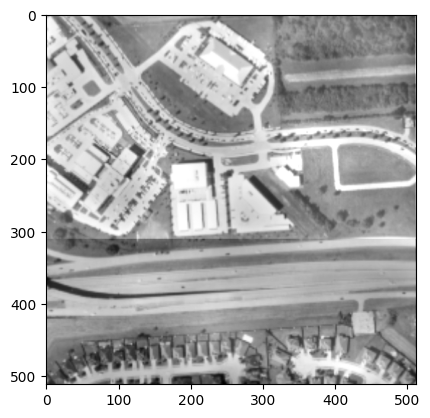

In [11]:
plt.imshow(sample['naip_hist'][1][0], cmap='gray')

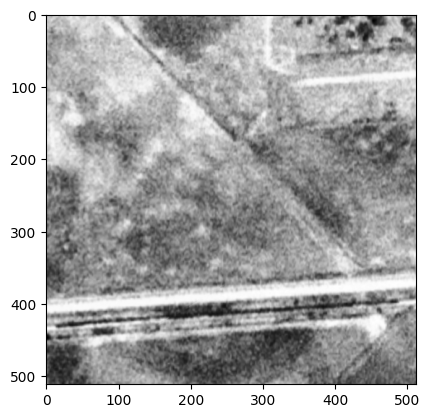

In [12]:
plt.imshow(sample['eros_hist'][1][0], cmap='gray')

In [52]:
# Accumulators
mean = 0
std = 0
total_images = 0

for i in range(z['naip_hist'].shape[0]):
    # images shape: [batch_size, channels, height, width]
    tile = z['naip_hist'][i][1]  # shape: [1, 1, 7000, 6000]
    labels = z['masks/urbanwatch'][i][0]  # shape: [1, 7000, 6000]

    masked = labels.flatten() != 0  # mask out empty

    images = tile.flatten()[masked] / 255.0
    mean += images.mean()
    std += images.std()
    total_images += 1

mean /= total_images
std /= total_images

mean, std

(np.float64(0.6493820041822563), np.float64(0.17010567701149337))

In [ ]:
(np.float64(0.6493820041822571), np.float64(0.1701056770114934))